# Template attack on a float32 weight (template-based DPA)

During profiling the weight is known, so for every trace the product `w*x` and therefore its leakage class is known.
For every class we measure what the power trace looks like at a few points of interest (POIs): a mean vector and a
covariance matrix, i.e. a Gaussian *template*. During the attack the weight is unknown. For each candidate weight we
compute which class every attack trace *would* belong to if the candidate were right, and score the traces with the
templates of those classes. The candidate whose classes explain the traces best is the weight.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal
import chipwhisperer as cw
from tqdm.auto import trange

/home/piskotka/.local/lib/python3.14/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


### Leakage model: Hamming weight of the top bits

A float32 weight is continuous: no candidate on a finite grid reproduces the product **bit for bit**, because a
tiny error in `w` scrambles the low mantissa bits of `w*x`. The **top** bits (sign, 8 exponent bits and the first
`k` mantissa bits) only change when `w` is far off. So the class of a trace is

`class = HW( top (9 + k) bits of float32(w * x) )`,  classes `0 ... 9+k`.

The unknown lower bits are not ignored, they are absorbed by the template: the covariance of a class already contains
the noise they cause. `k` is a knob:
- small `k`: robust to grid error, but different weights (e.g. `w` and `w/16`) look similar;
- large `k`: sharp, but demands a very fine candidate grid.

That is why the attack has a coarse and a fine stage with **two sets of templates**, one per `k`.

A third set uses all bits (`k = 23`, the full HW of the product). It has no absorbed noise from unknown bits, so every
trace carries several times more information, but it only fits a candidate that is **bit-exact**. It is used in the
last stage, once the fine stage has narrowed the weight down to a few ulps.

In [2]:
_HW16 = np.array([bin(i).count('1') for i in range(1 << 16)], dtype=np.uint8)   # popcount lookup table

def hwu(u):
    """Hamming weight of uint32 values (any shape)."""
    u = np.asarray(u, dtype=np.uint32)
    return _HW16[u & 0xFFFF] + _HW16[u >> 16]

def top_mask(k):
    keep = 9 + k
    return np.uint32((0xFFFFFFFF << (32 - keep)) & 0xFFFFFFFF)

def leak_class(product, k):
    """Leakage class of float32 products: HW of sign + exponent + top k mantissa bits."""
    return hwu(np.ascontiguousarray(product, dtype=np.float32).view(np.uint32) & top_mask(k)).astype(np.intp)

### Plots: TikZ export

Every plot is drawn by `plot`: it shows a matplotlib preview here and writes the same data as a pgfplots figure to
`results/figures/<name>.tex`. In the thesis (with `\usepackage{pgfplots}`) it is included with
`\input{../results/figures/<name>.tex}` inside a `figure` environment; the caption replaces the preview title.

A series is a dict with `x`, `y` and optionally `yerr` (error bars), `color` (a name known to both matplotlib and
xcolor), `label` (legend entry), `marker` (`'o'` or `'x'`) and `line` (`False` for points only).

In [3]:
import os

FIG_DIR = "../results/figures"
TIKZ_MAX_POINTS = 300          # longer series are thinned out in the .tex file to keep LaTeX fast

def _fmt(v):
    return f"{float(v):.6g}"

def plot(name, series, xlabel, ylabel, title=None, xlog=False, xlim=None, ylim=None,
         legend_pos="south east", figsize=(6.5, 3.8)):
    """Show a matplotlib preview and write the plot as a pgfplots figure to FIG_DIR/<name>.tex."""
    # matplotlib preview
    plt.figure(figsize=figsize)
    for s in series:
        ls = '-' if s.get('line', True) else 'none'
        kw = dict(color=s.get('color', 'blue'), label=s.get('label'), ls=ls, marker=s.get('marker'), ms=4)
        if s.get('yerr') is not None:
            plt.errorbar(s['x'], s['y'], yerr=s['yerr'], capsize=3, **kw)
        else:
            plt.plot(s['x'], s['y'], lw=s.get('lw', 1), **kw)
    if xlog:
        plt.xscale('log')
    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    if any(s.get('label') for s in series):
        plt.legend()
    plt.show()

    # pgfplots
    opts = [f"xlabel={{{xlabel}}}", f"ylabel={{{ylabel}}}", "width=0.9\\linewidth", "height=6cm",
            "grid=major", "grid style={gray!25}", f"legend pos={legend_pos}", "legend cell align=left"]
    if xlog:
        opts.append("xmode=log")
    if xlim:
        opts += [f"xmin={_fmt(xlim[0])}", f"xmax={_fmt(xlim[1])}"]
    if ylim:
        opts += [f"ymin={_fmt(ylim[0])}", f"ymax={_fmt(ylim[1])}"]
    out = ["\\begin{tikzpicture}", "\\begin{axis}[", *[f"  {o}," for o in opts], "]"]
    for s in series:
        x, y = np.asarray(s['x']), np.asarray(s['y'])
        idx = np.unique(np.linspace(0, len(x) - 1, min(len(x), TIKZ_MAX_POINTS)).round().astype(int))
        style = [s.get('color', 'blue'), "thick" if s.get('lw', 1) > 1 else "semithick"]
        style.append({'o': "mark=*, mark size=1.5pt", 'x': "mark=x, mark size=2.5pt"}.get(s.get('marker'), "no marks"))
        if not s.get('line', True):
            style.append("only marks")
        if not s.get('label'):
            style.append("forget plot")
        if s.get('yerr') is not None:
            e = np.asarray(s['yerr'])
            style.append(f"error bars/.cd, y dir=both, y explicit, error bar style={{{style[0]}}}")
            coords = " ".join(f"({_fmt(x[i])},{_fmt(y[i])}) +- (0,{_fmt(e[i] if e.ndim else e)})" for i in idx)
        else:
            coords = " ".join(f"({_fmt(x[i])},{_fmt(y[i])})" for i in idx)
        out.append(f"\\addplot[{', '.join(style)}] coordinates {{{coords}}};")
        if s.get('label'):
            out.append(f"\\addlegendentry{{{s['label']}}}")
    out += ["\\end{axis}", "\\end{tikzpicture}"]

    os.makedirs(FIG_DIR, exist_ok=True)
    path = os.path.join(FIG_DIR, f"{name}.tex")
    with open(path, "w") as f:
        f.write("\n".join(out) + "\n")
    print(f"saved {path}")

### Load the traces

`capture/capture.py` records two separate projects:
- **profiling project** (`textin = (input, weight)`): the firmware takes the weight from the payload, a new random
  weight for every trace. The weights are the **known labels** used to build the templates.
- **attack project** (`textin = (input,)`): the firmware is built with `IS_ATTACK_MODE` and multiplies by its fixed
  weight `lay1_weights[0][0]` from `firmware/network_config.h`. Only the inputs are known. The true weight is read
  from the header **only** to check the result.

In [4]:
import re

WINDOW = (0, 1000)          # only the start of the capture contains the network computation

def load_project(path):
    proj = cw.open_project(path)
    n = len(proj.waves)
    tr = np.array(proj.waves[:n], dtype=np.float32)[:, WINDOW[0]:WINDOW[1]].astype(np.float64)
    ti = np.array([np.atleast_1d(t) for t in proj.textins[:n]], dtype=np.float64)
    return tr, ti

p_traces, ti = load_project("../data/raw/profile")
p_inputs, p_weights = ti[:, 0].astype(np.float32), ti[:, 1].astype(np.float32)

a_traces, ti = load_project("../data/raw/attack")
a_inputs = ti[:, 0].astype(np.float32)

# ground truth (evaluation only): first weight of the first hidden neuron in the firmware
header = open("../firmware/network_config.h").read()
TRUE_W = float(np.float32(re.search(r"lay1_weights\[\d+\]\[\d+\]\s*=\s*\{\{\s*([-+\d.eE]+)", header).group(1)))

print(f"profiling: {len(p_traces)} traces, {len(np.unique(p_weights))} distinct weights in [{p_weights.min():+.3f}, {p_weights.max():+.3f}]")
print(f"attack:    {len(a_traces)} traces, true weight {TRUE_W:+.7f}")

profiling: 50000 traces, 500 distinct weights in [-1.994, +1.985]
attack:    5000 traces, true weight +1.4299999


### Points of interest (POIs)

The POIs are the samples that correlate most with the leakage (here: the Hamming weight of
the whole float32 product, known for the profiling traces). The product leaks at many samples, so many POIs are
used: neighbouring samples are correlated, but the pooled covariance accounts for that, and with 50k profiling traces
an 80x80 covariance is well estimated. (3 POIs needed ~190 attack traces for a 50% success rate, 80 POIs ~40.)

In [5]:
K_COARSE, K_FINE, K_EXACT = 8, 14, 23
N_POIS, POI_MIN_DIST = 5, 20    # the product leaks at many samples; the pooled covariance handles their correlation

labels = leak_class(p_inputs * p_weights, 23).astype(float)          # k = 23: all 32 bits of the product
t = p_traces - p_traces.mean(axis=0)
l = labels - labels.mean()
corr = (t * l[:, None]).sum(axis=0) / np.sqrt((t ** 2).sum(axis=0) * (l ** 2).sum())

POIS = []
for s in np.argsort(-np.abs(corr)):
    if all(abs(s - q) >= POI_MIN_DIST for q in POIS):
        POIS.append(int(s))
    if len(POIS) == N_POIS:
        break
POIS = sorted(POIS)
print("POIs:", POIS, " correlation with HW(product):", [f"{corr[s]:+.2f}" for s in POIS])

POIs: [518, 569, 622, 657, 737]  correlation with HW(product): ['-0.74', '-0.90', '-0.87', '-0.93', '-0.85']


### Step 1 — Build the templates

For every class `c` collect the leakage at the POIs of all profiling traces whose product falls in class `c` and
compute the mean vector `mu_c` (one number per POI). Together with a covariance matrix `Sigma` this defines a
multivariate Gaussian `N(mu_c, Sigma)`: "what the POIs look like when the product is in class `c`".

There are up to 24 classes and the ones in the tails have few profiling traces, so:

- **Pooled covariance.** Classes in the tails have only a handful of profiling traces, which makes a per-class
  covariance unreliable, so one covariance matrix is estimated from the within-class scatter of *all* classes
  (a *pooled template*).
- **Extrapolated means for rare classes.** A class with fewer than `MIN_COUNT` profiling traces gets its mean from a
  straight line fitted through the means of the well-populated classes (the leakage is roughly linear in the Hamming
  weight). A hypothesis that needs a class that never occurs is then not "impossible" but simply very unlikely,
  because its mean is far from what the trace shows. This also handles candidates like `w = 0` (product 0, class 0).

`INDEPENDENT_POIS = True` replaces the covariance by its diagonal, i.e. POIs are assumed to be independent.

In [6]:
INDEPENDENT_POIS = False
MIN_COUNT = 30

def build_template(k):
    n_cls = 9 + k + 1
    cls = leak_class(p_inputs * p_weights, k)
    leak = p_traces[:, POIS]
    P = len(POIS)

    count = np.bincount(cls, minlength=n_cls)
    valid = count >= MIN_COUNT
    mean = np.zeros((n_cls, P))
    scatter = np.zeros((P, P))
    for c in np.flatnonzero(valid):
        d = leak[cls == c]
        mean[c] = d.mean(axis=0)
        scatter += (d - mean[c]).T @ (d - mean[c])
    cov = scatter / count[valid].sum()                                   # pooled covariance
    if INDEPENDENT_POIS:
        cov = np.diag(np.diag(cov))

    # rare classes: mean from a line through the well-populated classes
    cv = np.flatnonzero(valid)
    for p in range(P):
        slope, icpt = np.polyfit(cv, mean[cv, p], 1, w=np.sqrt(count[cv]))
        mean[~valid, p] = icpt + slope * np.flatnonzero(~valid)

    return dict(k=k, mean=mean, inv_cov=np.linalg.inv(cov), cov=cov, valid=valid, count=count)

tpl_coarse, tpl_fine, tpl_exact = build_template(K_COARSE), build_template(K_FINE), build_template(K_EXACT)
for name, tp in (('coarse', tpl_coarse), ('fine', tpl_fine), ('exact', tpl_exact)):
    print(f"{name} templates (k={tp['k']}): {tp['valid'].sum()} of {len(tp['valid'])} classes measured, the others extrapolated")

coarse templates (k=8): 11 of 18 classes measured, the others extrapolated
fine templates (k=14): 13 of 24 classes measured, the others extrapolated
exact templates (k=23): 16 of 33 classes measured, the others extrapolated


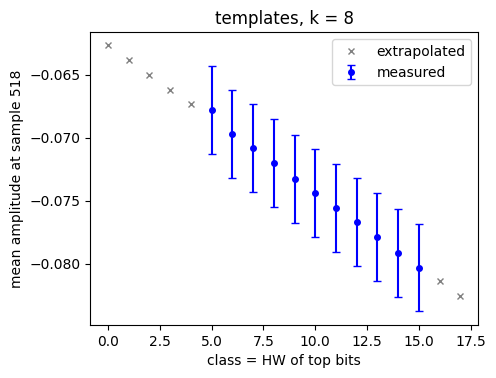

saved ../results/figures/templates_k8.tex


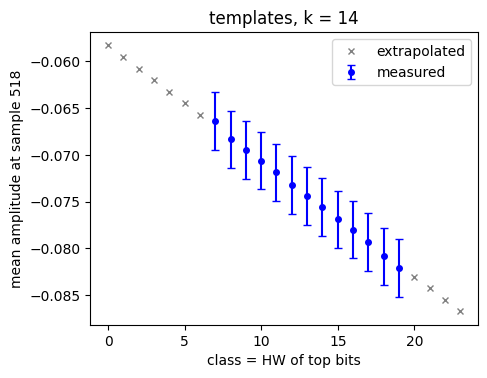

saved ../results/figures/templates_k14.tex


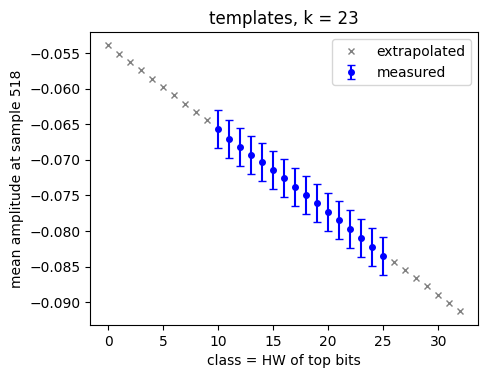

saved ../results/figures/templates_k23.tex


In [7]:
# The templates: mean amplitude at the first POI for every class (error bars: standard deviation)
for tp in (tpl_coarse, tpl_fine, tpl_exact):
    cl = np.arange(len(tp['valid']))
    v = tp['valid']
    plot(f"templates_k{tp['k']}",
         [dict(x=cl[v], y=tp['mean'][v, 0], yerr=np.sqrt(tp['cov'][0, 0]), marker='o', line=False,
               color='blue', label='measured'),
          dict(x=cl[~v], y=tp['mean'][~v, 0], marker='x', line=False, color='gray', label='extrapolated')],
         xlabel='class = HW of top bits', ylabel=f'mean amplitude at sample {POIS[0]}',
         title=f"templates, k = {tp['k']}", legend_pos='north east', figsize=(5, 3.8))

### Step 2 — Score the candidate weights

For a candidate weight `w` and attack trace `j` (input `x_j`, leakage `t_j` at the POIs):

1. hypothetical class `c = HW(top bits of w * x_j)`;
2. log-likelihood of the trace under the template of that class

   `ll(j, w) = -1/2 * (t_j - mu_c)^T  Sigma^-1  (t_j - mu_c)`

   (the `ln |Sigma|` term is the same for all classes with one pooled covariance and drops out);
3. score of the candidate: `sum_j ll(j, w)` (the traces are independent given their class, so log-likelihoods add).

The candidate with the highest score is the recovered weight. All candidate weights are scored, vectorised in chunks.

`ll(j, w)` depends on `w` only through the class `c`, and there are at most 24 classes. So `ll` is computed once per
trace and class (`class_loglik`), and scoring a candidate only looks up the right entry for each trace.

In [8]:
CHUNK = 2000          # candidates per batch (memory)

def class_loglik(leak, tpl):
    """Log-likelihood of every trace under the template of every class -> array (traces, classes)."""
    d = leak[:, None, :] - tpl['mean'][None, :, :]                        # (traces, classes, POIs)
    return -0.5 * np.einsum('ncp,pq,ncq->nc', d, tpl['inv_cov'], d)

def per_trace_loglik(cands, x, leak, tpl):
    """Log-likelihood of every attack trace under every candidate weight -> array (candidates, traces).
    cands: float32 candidate weights, x: known inputs, leak: trace amplitudes at the POIs, shape (traces, POIs)."""
    table = class_loglik(leak, tpl)
    cols = np.arange(len(x))
    out = np.empty((len(cands), len(x)))
    for i in range(0, len(cands), CHUNK):
        prod = (cands[i:i + CHUNK, None] * x[None, :]).astype(np.float32)
        c = leak_class(prod, tpl['k'])                                   # hypothetical class of each trace
        out[i:i + CHUNK] = table[cols, c]
    return out

### Step 3 — Recover a weight: coarse, fine, then exact

1. **Coarse**: score every candidate of a grid over [-`W_MAX`, `W_MAX`] with the coarse templates (`K_COARSE`) and
   keep the best few *distinct* peaks (finalists). `W_MAX = 2` covers every weight in `network_config.h`.
2. **Fine**: around every finalist score a much finer local grid with the fine templates (`K_FINE`). The finalists are
   compared with each other at the same fine resolution, and the best one is kept.
3. **Exact**: score every float32 within `EXACT_ULPS` ulps of the fine result bit-exactly with the full-HW templates
   (`K_EXACT`), together with its sign flip and its power-of-two variants `w * 2^j` (`EXACT_EXPS`). The best one is
   the recovered weight.

The coarse templates are robust to the grid error but cannot separate look-alikes such as `w` and `w/16`; the fine
templates can, but only near the right value. The look-alikes `±w * 2^j` have exactly the same mantissa bits, so only
the few exponent and sign bits of the product tell them apart. With `K_FINE` that difference drowns in the noise of the
unknown low bits; the exact stage removes that noise and separates them with far fewer traces.

`recover_weight` is split into the coarse scoring and `refine`, so the success-rate experiment below can reuse the
coarse scores.

In [9]:
W_MAX = Decimal('2.0')
COARSE_STEP = Decimal('0.0001')
FINE_STEP, FINE_HALF_WIDTH = 1e-6, 1e-4
N_FINALISTS, FINALIST_SEP = 6, 0.005
EXACT_ULPS = 512                 # ulps around the fine result searched bit-exactly; with few traces the fine result can be
                                 # hundreds of ulps off, and a look-alike w/2^j has FINE_STEP worth 2^j times more ulps
EXACT_EXPS = np.arange(-10, 11)  # power-of-two variants w * 2^j that are also scored, in both directions:
                                 # the fine stage may land on w/16 and then w = fine * 2^4 must be reachable

grid = np.float32([float(-W_MAX + COARSE_STEP * i) for i in range(int(2 * W_MAX / COARSE_STEP) + 1)])
n_fine = int(round(FINE_HALF_WIDTH / FINE_STEP))
fine_offsets = np.arange(-n_fine, n_fine + 1) * FINE_STEP

def exact_stage(w0, x, leak):
    """Score float32 values within EXACT_ULPS ulps of w0, with both signs and scaled by 2^j, with the exact templates."""
    base = np.float32(w0).view(np.int32)
    near = (base + np.arange(-EXACT_ULPS, EXACT_ULPS + 1)).astype(np.int32).view(np.float32)   # neighbouring floats
    cands = np.concatenate([s * near * np.float32(2.0 ** j) for s in (1, -1) for j in EXACT_EXPS]).astype(np.float32)
    cands = cands[np.abs(cands) <= float(W_MAX)]
    s = per_trace_loglik(cands, x, leak, tpl_exact).sum(axis=1)
    return float(cands[np.argmax(s)])

def refine(coarse, x, leak):
    """Pick the finalists from the coarse scores (one per grid candidate), refine them with the fine templates and
    settle the best one with the exact stage. Returns the weight and the refined finalists as (weight, score) pairs."""
    fin = []
    for i in np.argsort(coarse)[::-1]:
        if all(abs(grid[i] - grid[j]) > FINALIST_SEP for j in fin):
            fin.append(i)
        if len(fin) == N_FINALISTS:
            break
    refined = []
    for i in fin:
        fine_c = float(grid[i]) + fine_offsets
        s = per_trace_loglik(fine_c.astype(np.float32), x, leak, tpl_fine).sum(axis=1)
        j = int(np.argmax(s))
        refined.append((fine_c[j], s[j]))
    best = exact_stage(max(refined, key=lambda r: r[1])[0], x, leak)
    return best, refined

def recover_weight(x, leak):
    """Recover the weight from known inputs x and the trace amplitudes at the POIs."""
    return refine(per_trace_loglik(grid, x, leak, tpl_coarse).sum(axis=1), x, leak)

### Score against the number of traces

The accumulated score of every hypothesis while the
attack traces are added one by one. The **blue** line is the true weight (only known here for the evaluation), the grey
lines are the other finalists of the search. A correct attack shows blue rising above all grey lines.

true weight +1.4299999, recovered +1.4299999 from 1000 traces


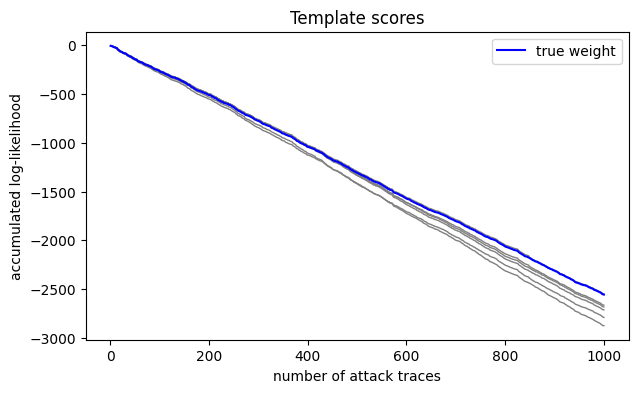

saved ../results/figures/template_scores.tex


In [10]:
N_SCORE_PLOT = 1000          # attack traces shown in the plot
x, leak = a_inputs[:N_SCORE_PLOT], a_traces[:N_SCORE_PLOT][:, POIS]
best, refined = recover_weight(x, leak)
print(f"true weight {TRUE_W:+.7f}, recovered {best:+.7f} from {len(x)} traces")

hyp = np.float32([r[0] for r in refined] + [TRUE_W])                 # finalists + the true weight
ll = per_trace_loglik(hyp, x, leak, tpl_fine)
cum = np.cumsum(ll, axis=1)

n_tr = np.arange(1, len(x) + 1)
plot("template_scores",
     [dict(x=n_tr, y=cum[i], color='gray') for i in range(len(hyp) - 1)]
     + [dict(x=n_tr, y=cum[-1], color='blue', lw=1.5, label='true weight')],
     xlabel='number of attack traces', ylabel='accumulated log-likelihood', title='Template scores',
     legend_pos='south west', figsize=(7, 4))

### Attack with all attack traces

Recover the weight from the whole attack set and compare with the ground truth. The weight counts as recovered when
it is within `TOL` of the true value.

In [11]:
TOL = 5e-6
rec, _ = recover_weight(a_inputs, a_traces[:, POIS])
print(f"true {TRUE_W:+.7f}  recovered {rec:+.7f}  error {abs(rec - TRUE_W):.1e}  "
      f"{'OK' if abs(rec - TRUE_W) <= TOL else 'MISS'}  ({len(a_inputs)} traces)")

true +1.4299999  recovered +1.4299999  error 0.0e+00  OK  (5000 traces)


### Success rate against the number of attack traces

Repeat the attack `N_REPEATS` times on random subsets of the attack traces
and count how often the weight is recovered for every number of traces `m`.

Every repeat draws one random order of `MAX_TRACES` attack traces and attacks its first `m` traces for all `m` in
`TRACE_COUNTS` (nested subsets, as usual for success-rate curves). The coarse scores then only have to be computed
once per repeat: the score of the first `m` traces is a cumulative sum. Only the cheap fine stage runs for every `m`,
so the curve can have many points.

success rate:   0%|          | 0/100 [00:00<?, ?it/s]

    1 traces: success rate 0.00
    2 traces: success rate 0.00
    3 traces: success rate 0.00
    4 traces: success rate 0.00
    6 traces: success rate 0.00
    7 traces: success rate 0.00
    9 traces: success rate 0.01
   11 traces: success rate 0.03
   13 traces: success rate 0.06
   16 traces: success rate 0.07
   20 traces: success rate 0.21
   25 traces: success rate 0.35
   31 traces: success rate 0.44
   38 traces: success rate 0.64
   47 traces: success rate 0.73
   59 traces: success rate 0.79
   73 traces: success rate 0.88
   90 traces: success rate 0.89
  112 traces: success rate 0.92
  138 traces: success rate 0.95
  171 traces: success rate 0.99
  212 traces: success rate 0.98
  263 traces: success rate 1.00
  326 traces: success rate 1.00
  404 traces: success rate 1.00
  500 traces: success rate 1.00


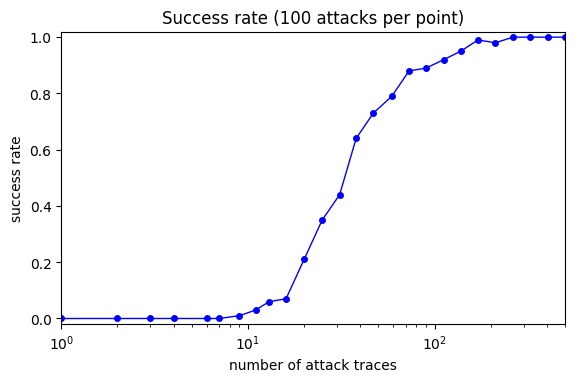

saved ../results/figures/success_rate.tex


In [13]:
MAX_TRACES = min(500, len(a_inputs))
TRACE_COUNTS = np.unique(np.round(np.logspace(0, np.log10(MAX_TRACES), 30)).astype(int))
N_REPEATS = 100

rng = np.random.default_rng(0)
a_leak = a_traces[:, POIS]
hits = np.zeros((N_REPEATS, len(TRACE_COUNTS)), dtype=bool)
for r in (bar := trange(N_REPEATS, desc='success rate')):
    sub = rng.permutation(len(a_inputs))[:MAX_TRACES]
    x, leak = a_inputs[sub], a_leak[sub]
    cum = np.cumsum(per_trace_loglik(grid, x, leak, tpl_coarse), axis=1)
    for j, m in enumerate(TRACE_COUNTS):
        rec, _ = refine(cum[:, m - 1], x[:m], leak[:m])
        hits[r, j] = abs(rec - TRUE_W) <= TOL
    bar.set_postfix(sr_max=f"{hits[:r + 1, -1].mean():.2f}")      # success rate at MAX_TRACES so far
sr = hits.mean(axis=0)

for m, s in zip(TRACE_COUNTS, sr):
    print(f"{m:5d} traces: success rate {s:.2f}")

plot("success_rate",
     [dict(x=TRACE_COUNTS, y=sr, marker='o', color='blue')],
     xlabel='number of attack traces', ylabel='success rate', title=f'Success rate ({N_REPEATS} attacks per point)',
     xlog=True, xlim=(1, MAX_TRACES), ylim=(-0.02, 1.02))
